# Metro Traffic Data Exploration

This notebook explores the metro traffic dataset for the CityFlow ML project.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## Load Data

In [2]:
df = pd.read_csv('../data/metro_traffic.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (48204, 9)

First 5 rows:


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


## Basic Data Exploration

In [3]:
print("Dataset Info:")
df.info()

print("\n" + "="*50 + "\n")

print("Statistical Summary:")
df.describe()

print("\n" + "="*50 + "\n")

print("Missing Values:")
df.isnull().sum()

print("\n" + "="*50 + "\n")

print("Number of duplicate rows:", df.duplicated().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


Statistical Summary:


Missing Values:


Number of duplicate rows: 17


## Traffic Volume Distribution

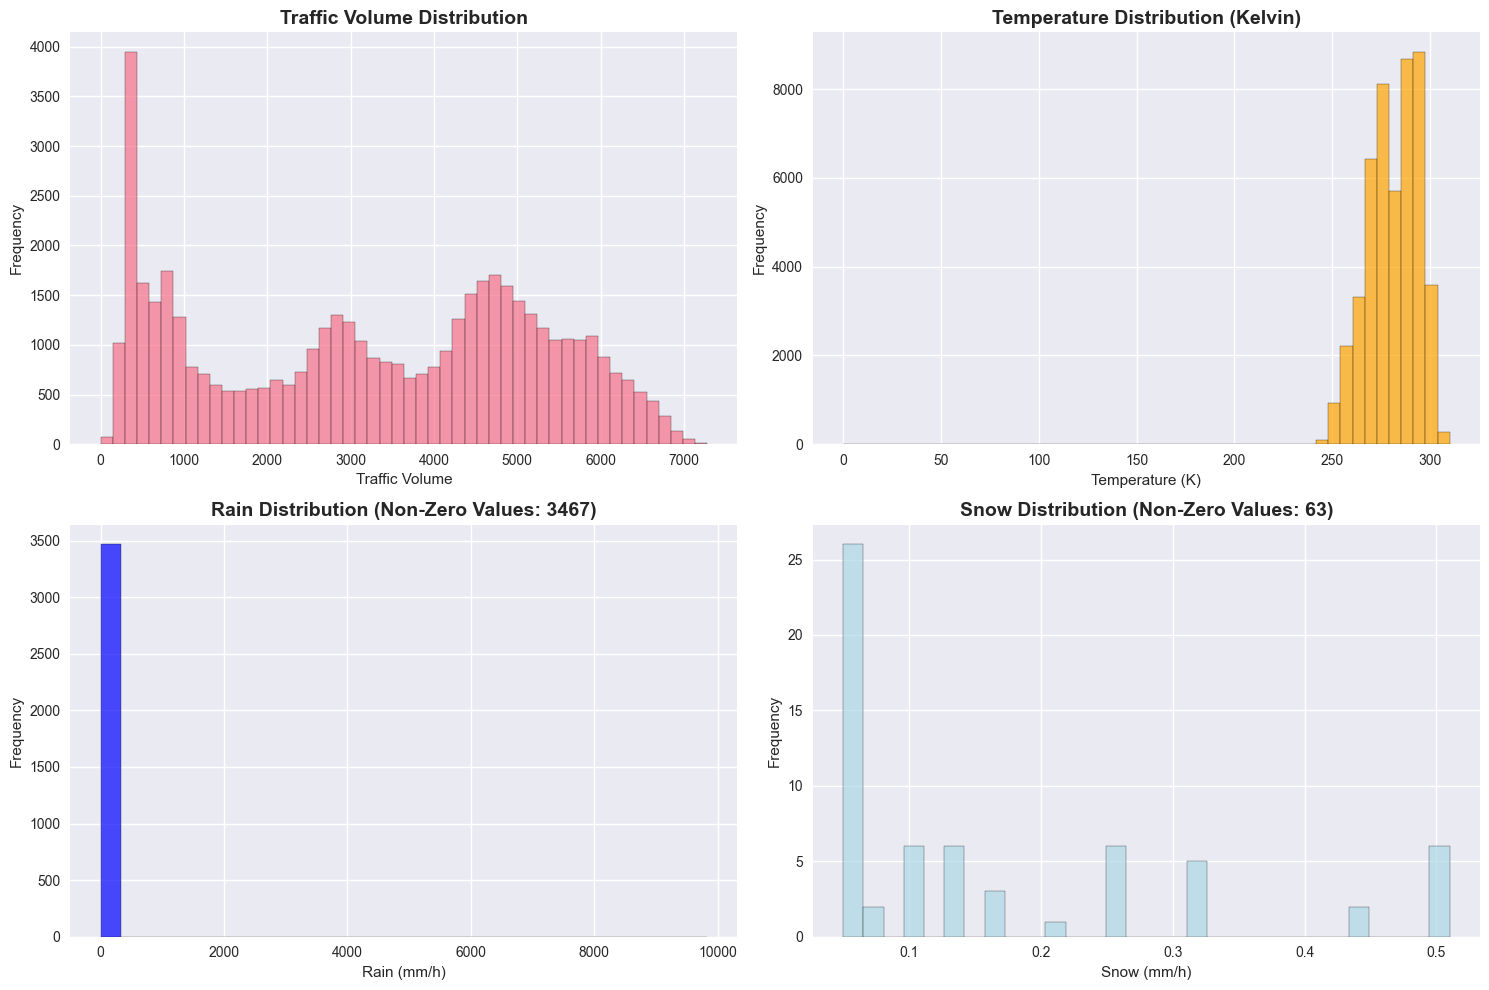

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Traffic volume distribution
axes[0, 0].hist(df['traffic_volume'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Traffic Volume Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Traffic Volume')
axes[0, 0].set_ylabel('Frequency')

# Temperature distribution
axes[0, 1].hist(df['temp'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Temperature Distribution (Kelvin)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Temperature (K)')
axes[0, 1].set_ylabel('Frequency')

# Rain distribution (non-zero values)
rain_data = df[df['rain_1h'] > 0]['rain_1h']
axes[1, 0].hist(rain_data, bins=30, edgecolor='black', alpha=0.7, color='blue')
axes[1, 0].set_title(f'Rain Distribution (Non-Zero Values: {len(rain_data)})', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Rain (mm/h)')
axes[1, 0].set_ylabel('Frequency')

# Snow distribution (non-zero values)
snow_data = df[df['snow_1h'] > 0]['snow_1h']
axes[1, 1].hist(snow_data, bins=30, edgecolor='black', alpha=0.7, color='lightblue')
axes[1, 1].set_title(f'Snow Distribution (Non-Zero Values: {len(snow_data)})', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Snow (mm/h)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Traffic Patterns Over Time

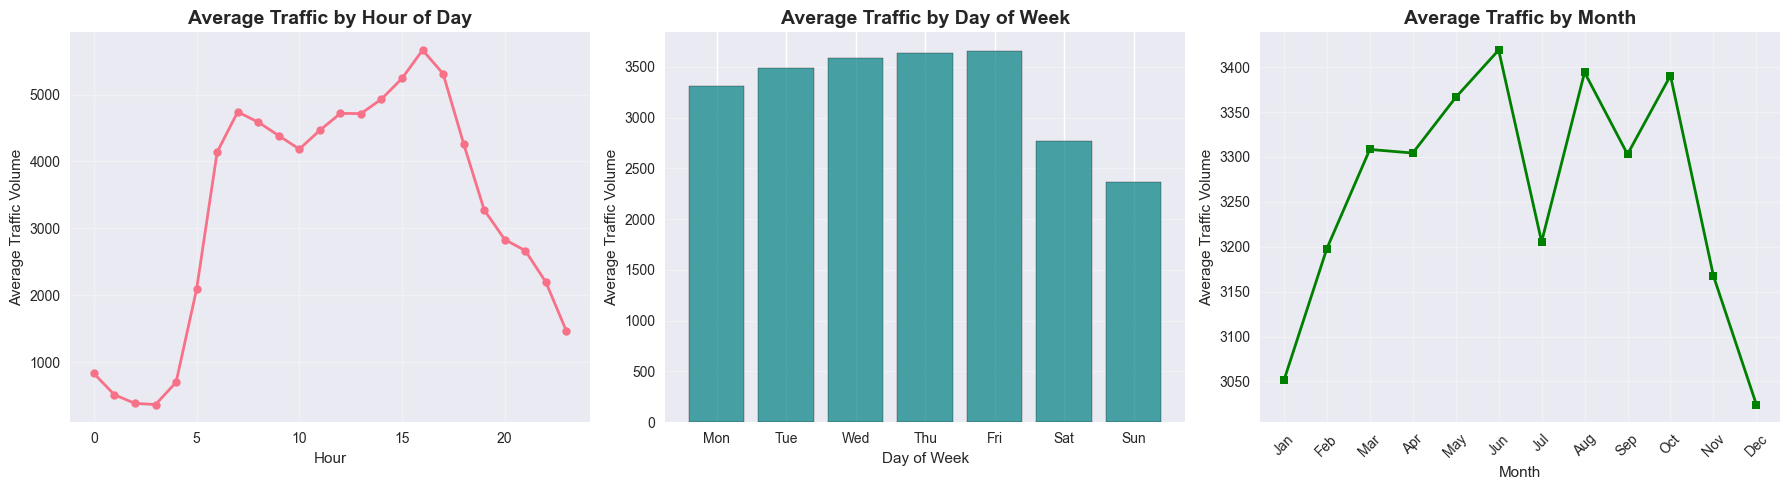

In [5]:
# Convert date_time to datetime
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Traffic by hour of day
hourly_traffic = df.groupby('hour')['traffic_volume'].mean()
axes[0].plot(hourly_traffic.index, hourly_traffic.values, marker='o', linewidth=2, markersize=6)
axes[0].set_title('Average Traffic by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average Traffic Volume')
axes[0].grid(True, alpha=0.3)

# Traffic by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_traffic = df.groupby('day_of_week')['traffic_volume'].mean()
axes[1].bar(range(7), daily_traffic.values, color='teal', alpha=0.7, edgecolor='black')
axes[1].set_title('Average Traffic by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Traffic Volume')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_names)
axes[1].grid(True, alpha=0.3, axis='y')

# Traffic by month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_traffic = df.groupby('month')['traffic_volume'].mean()
axes[2].plot(monthly_traffic.index, monthly_traffic.values, marker='s', linewidth=2, markersize=6, color='green')
axes[2].set_title('Average Traffic by Month', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Traffic Volume')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_names, rotation=45)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Weather Impact on Traffic

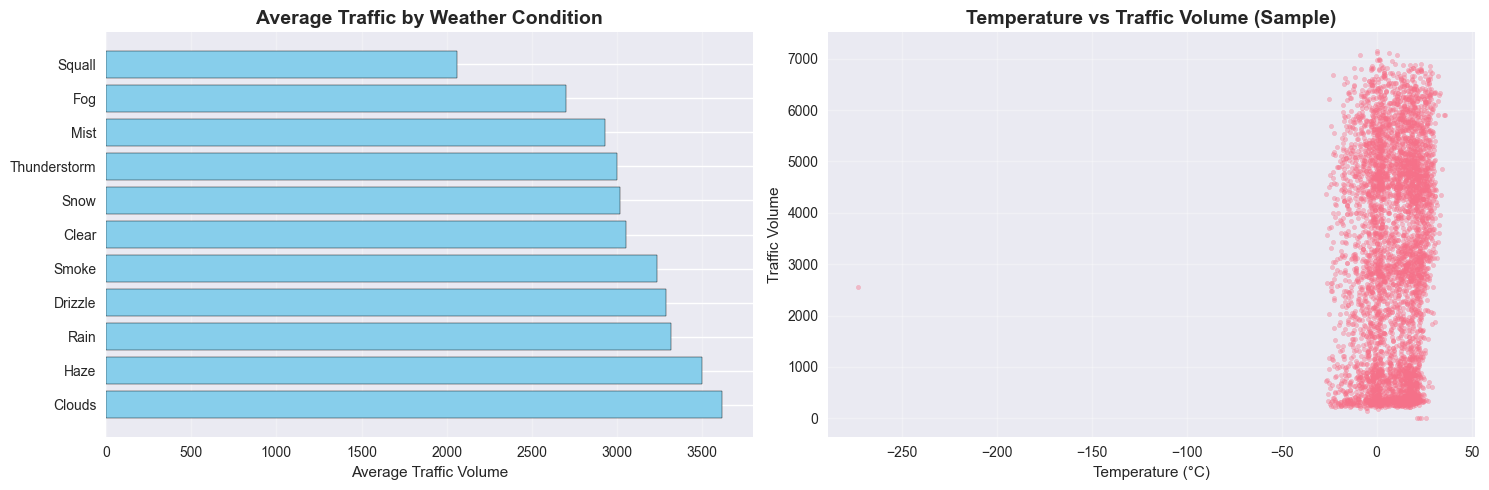

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Traffic by weather condition
weather_traffic = df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False)
axes[0].barh(range(len(weather_traffic)), weather_traffic.values, color='skyblue', edgecolor='black')
axes[0].set_yticks(range(len(weather_traffic)))
axes[0].set_yticklabels(weather_traffic.index)
axes[0].set_xlabel('Average Traffic Volume')
axes[0].set_title('Average Traffic by Weather Condition', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Temperature vs Traffic (scatter sample)
sample_df = df.sample(n=min(5000, len(df)), random_state=42)
temp_celsius = sample_df['temp'] - 273.15
axes[1].scatter(temp_celsius, sample_df['traffic_volume'], alpha=0.4, s=10)
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Traffic Volume')
axes[1].set_title('Temperature vs Traffic Volume (Sample)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation Matrix

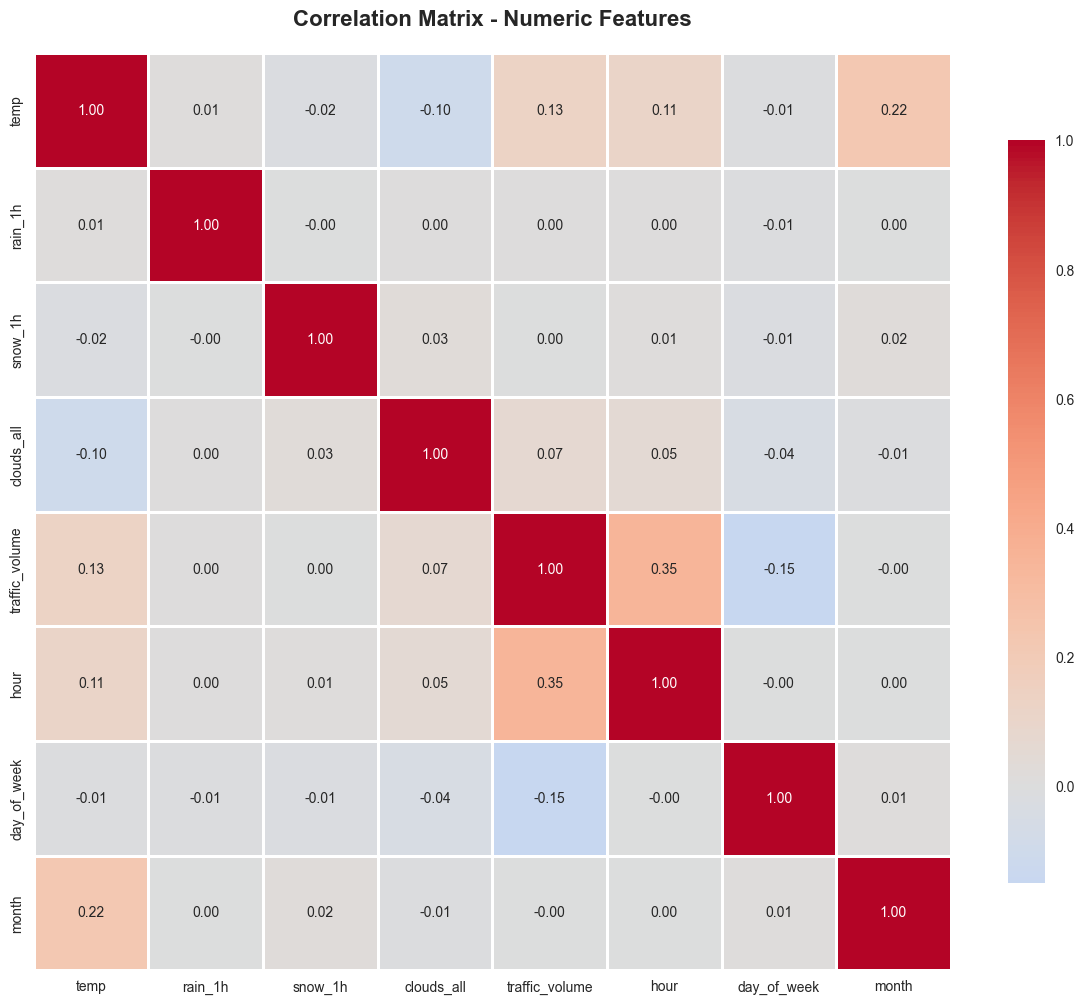


Strongest correlations with traffic_volume:
traffic_volume    1.000000
hour              0.352401
temp              0.130299
clouds_all        0.067054
rain_1h           0.004714
snow_1h           0.000733
month            -0.002533
day_of_week      -0.149544
Name: traffic_volume, dtype: float64


In [7]:
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show strongest correlations with traffic_volume
print("\nStrongest correlations with traffic_volume:")
print("=" * 50)
traffic_corr = correlation_matrix['traffic_volume'].sort_values(ascending=False)
print(traffic_corr)

## Box Plots for Outlier Detection

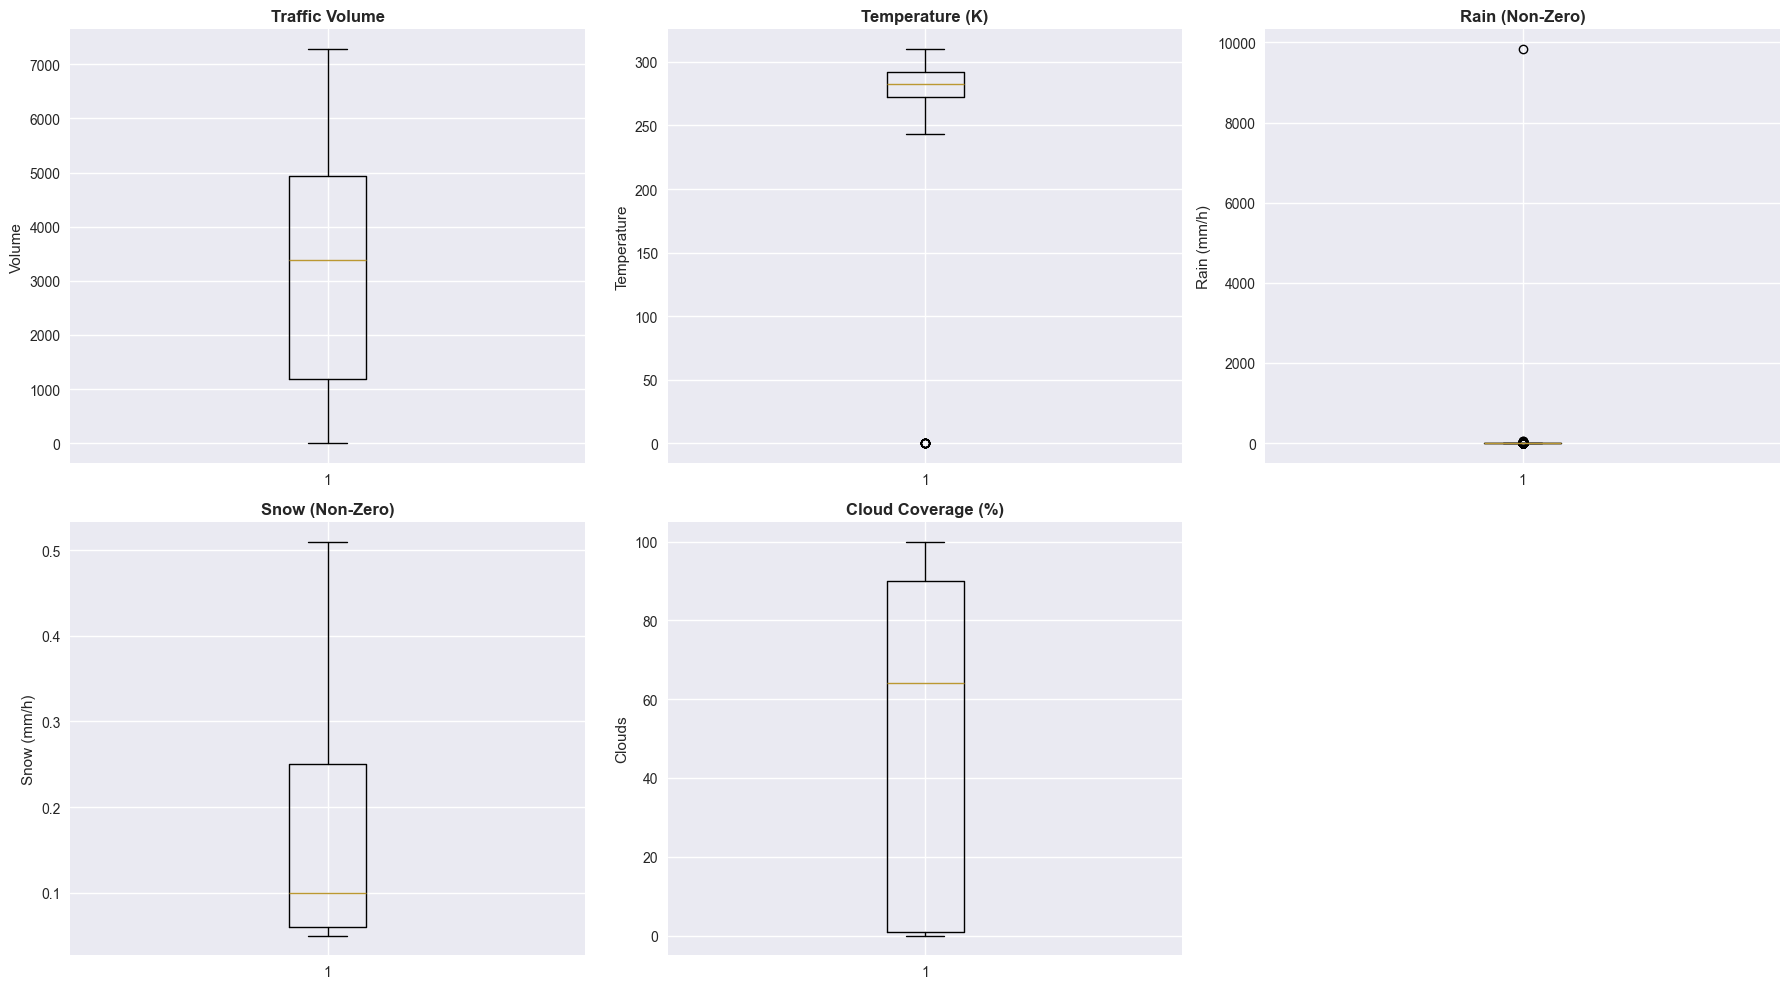

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Traffic volume
axes[0, 0].boxplot(df['traffic_volume'], vert=True)
axes[0, 0].set_title('Traffic Volume', fontweight='bold')
axes[0, 0].set_ylabel('Volume')

# Temperature
axes[0, 1].boxplot(df['temp'], vert=True)
axes[0, 1].set_title('Temperature (K)', fontweight='bold')
axes[0, 1].set_ylabel('Temperature')

# Rain (non-zero only)
axes[0, 2].boxplot(df[df['rain_1h'] > 0]['rain_1h'], vert=True)
axes[0, 2].set_title('Rain (Non-Zero)', fontweight='bold')
axes[0, 2].set_ylabel('Rain (mm/h)')

# Snow (non-zero only)
axes[1, 0].boxplot(df[df['snow_1h'] > 0]['snow_1h'], vert=True)
axes[1, 0].set_title('Snow (Non-Zero)', fontweight='bold')
axes[1, 0].set_ylabel('Snow (mm/h)')

# Clouds
axes[1, 1].boxplot(df['clouds_all'], vert=True)
axes[1, 1].set_title('Cloud Coverage (%)', fontweight='bold')
axes[1, 1].set_ylabel('Clouds')

# Remove empty subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()